## 1. Importazioni / Imports

**In italiano:** Importiamo le librerie necessarie per il progetto. Usiamo `langchain_google_genai` per il modello linguistico, `DuckDuckGoSearchRun` come tool di ricerca esterna e `langgraph` per creare il nostro grafo di agenti.

**In English:** Import the necessary libraries for the project. We use `langchain_google_genai` for the language model, `DuckDuckGoSearchRun` as an external search tool, and `langgraph` to create our agent graph.

In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.graph import StateGraph, START, END
from langchain.tools import tool
from langgraph.prebuilt import ToolNode
from typing import Annotated, TypedDict, Any
from langchain_core.messages import HumanMessage
from IPython.display import Image, display

## 2. Definizione degli Stati / State Definition

**In italiano:** Gli stati che verranno realizzati per il seguente progetto saranno 3:
* **InputState**: Uno stato di input, per permettere all'utente di inserire solo la query iniziale.
* **HiddenState**: Uno stato nascosto, il cui accesso alle informazioni è permesso solamente alle funzioni interne del grafo (es. memorizzare le ricerce).
* **OutputState**: Uno stato di output, che conterrà solamente la risposta finale generata dall'LLM.

**In English:** The states that will be implemented for this project will be 3:
* **InputState**: An input state to allow the user to input only the initial query.
* **HiddenState**: A hidden state whose access is allowed only to internal functions of the graph (e.g. to store search results).
* **OutputState**: An output state that holds only the final response generated by the LLM.

In [2]:
class InputState(TypedDict):
    query: str

class HiddenState(TypedDict):
    query: str
    researches: list[Any]
    response: str

class OutputState(TypedDict):
    response: str

## 3. Inizializzazione dell'LLM / LLM Initialization

**In italiano:** Per questo progetto è stato scelto di utilizzare `gemini-3.1-flash-lite-preview`. I limiti messi a disposizione dall'utilizzo della chiave gratuita sono sufficienti per lo sviluppo del progetto.

**In English:** For this project, it was decided to use `gemini-3.1-flash-lite-preview`. The limits provided by the free tier key are sufficient for the development of the project.

In [3]:
llm = ChatGoogleGenerativeAI(model='gemini-3.1-flash-lite-preview')

## 4. Definizione dei Nodi / Nodes Definition

**In italiano:** Definiamo i nodi del grafo.
- `search_node`: esegue la ricerca su `DuckDuckGo` e salva i risultati nell'`HiddenState`.
- `generate_answer`: usa le informazioni trovate per far generare all'LLM un'analisi chiedendo se la news è vera o falsa, restituendo i dati all'`OutputState` e salvandoli per ora nell'`HiddenState`.

**In English:** Let's define the graph nodes.
- `search_node`: performs a search on `DuckDuckGo` and saves the results in `HiddenState`.
- `generate_answer`: uses the retrieved information to have the LLM analyze whether the news is fake or not, returning the structured final response.

In [4]:
def search_node(state: HiddenState):
    search = DuckDuckGoSearchRun()
    # Eseguiamo la ricerca usando la query nello stato / Execute search using state's query
    results = search.invoke(state['query'])
    # Ritorniamo il dizionario che aggiorna lo stato / Return dict to update the state
    return {'researches': [results]}

def generate_answer(state: HiddenState):
    final_prompt = f"""
    Analizza se questa news è fake o meno in modo professionale.
    News utente: {state['query']}
    Risultati ricerche: {state['researches']}
    Rispondi in italiano.
    """
    # LLM Inference
    res = llm.invoke(final_prompt)
    return {'response': res.content}

## 5. Compilazione del Grafo / Graph Compilation

**In italiano:** Adesso assembliamo il `workflow`. Configuriamo il grafo specificando `InputState`, `HiddenState` e `OutputState`. Poi agganciamo i nodi (`search_news` e `response`) e definiamo le transizioni (inclusi i collegamenti condizionali). 

**In English:** Now we assemble the `workflow`. We configure the graph typing it with `InputState`, `HiddenState`, and `OutputState`. Then we add nodes (`search_news` and `response`) and define edges (including conditional edges).

In [ ]:
# Configurazione degli stati del workflow
workflow = StateGraph(state_schema=HiddenState, input_schema=InputState, output_schema=OutputState)

workflow.add_node("search_news", search_node)
workflow.add_node("response", generate_answer)

workflow.add_edge(START, "search_news")
workflow.add_edge("search_news", "response")
workflow.add_edge("response", END)

app = workflow.compile()

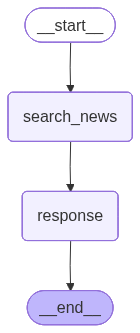

In [6]:
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # Se non hai le dipendenze locali per Mermaid, 
    # questo metodo è il più affidabile nei notebook
    print("Errore nella generazione dell'immagine. Verifica le dipendenze.")

## 6. Test e Invocazione / Test and Invocation

**In italiano:** Testiamo il grafo passando i dati di input corretti conformi all'`InputState`.

**In English:** Let's test the graph by passing the correct input data conforming to `InputState`.

In [ ]:
input_data = {"query": "Addio Bastoni, netta posizione dell’Inter: annuncio di Romano"}
result = app.invoke(input_data)

print(result['response'][0]['text'])